# Antibunching of 4 fluorophores in different conditions

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi

%load_ext autoreload
%autoreload 2

reading_from = r"D:\python_output\Chapter_I\1_12_multi_f_antibunching"

## Reading the data

In [16]:
reading_from_OET = reading_from + r"\OET"
reading_from_noOET = reading_from + r"\noOET"
reading_from_OEThighSSA = reading_from + r"\OEThighSSA"
reading_from_OETnoSSA = reading_from + r"\OETnoSSA"
reading_from_noDSTORM = reading_from + r"\noDSTORM"
reading_from_noDSTORMrisc = reading_from + r"\noDSTORMrisc"
reading_from_noDSTORMlowrisc = reading_from + r"\noDSTORMlowrisc"
reading_from_OETrisc = reading_from + r"\OETrisc"
reading_from_noOETnoSSA = reading_from + r"\noOETnoSSA"

all_folders = [
    reading_from_OET,
    reading_from_noOET,
    reading_from_OEThighSSA,
    reading_from_OETnoSSA,
    reading_from_noDSTORM,
    reading_from_noDSTORMrisc,
    reading_from_noDSTORMlowrisc,
    reading_from_OETrisc,
    reading_from_noOETnoSSA,
]

red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

In [ ]:
rng = np.random.default_rng(42)

all_data_coincidence = []
all_data_coincidence_truncated = []
all_data_time_series = []
maxima = np.zeros((9, 4))
identifiers = ["3nm", "6nm", "9nm", "18nm"]
for i, r_from in enumerate(all_folders):
    all_data_coincidence.append([])
    all_data_coincidence_truncated.append([])
    all_data_time_series.append([])
    for j, id in enumerate(identifiers):
        for file in Path(r_from).iterdir():
            if file.name == f"event_time_points_{id}.npy":
                event_time_points = np.load(file)
                event_time_points_ = (
                    event_time_points[:3000000]
                    if event_time_points.shape[0] > 3000000
                    else event_time_points
                )
                hist, bins = fcs_p.coincidence_with_normalization(
                    event_time_points_,
                    tau_max=1e-7,
                    bin_width=5e-10,
                    seed=rng,
                    method="numba",
                )
                all_data_coincidence[i].append([hist, bins])
                min_index = np.where(event_time_points_ > 20e-3)[0][0]
                event_time_points_truncated = event_time_points_[min_index:]
                hist_truncated, bins_truncated = fcs_p.coincidence_with_normalization(
                    event_time_points_truncated,
                    tau_max=1e-7,
                    bin_width=5e-10,
                    seed=rng,
                    method="numba",
                )
                all_data_coincidence_truncated[i].append(
                    [hist_truncated, bins_truncated]
                )
            if file.name == f"event_time_series_{id}.parquet":
                emis = em.Emissions()
                emis.event_time_series = pd.read_parquet(file)
                all_data_time_series[i].append(emis)
                maxima[i, j] = np.max(emis.event_time_series)

## Coincidence plots

Text(0.5, 0.04, 'Delay ($10^-7$ x s)')

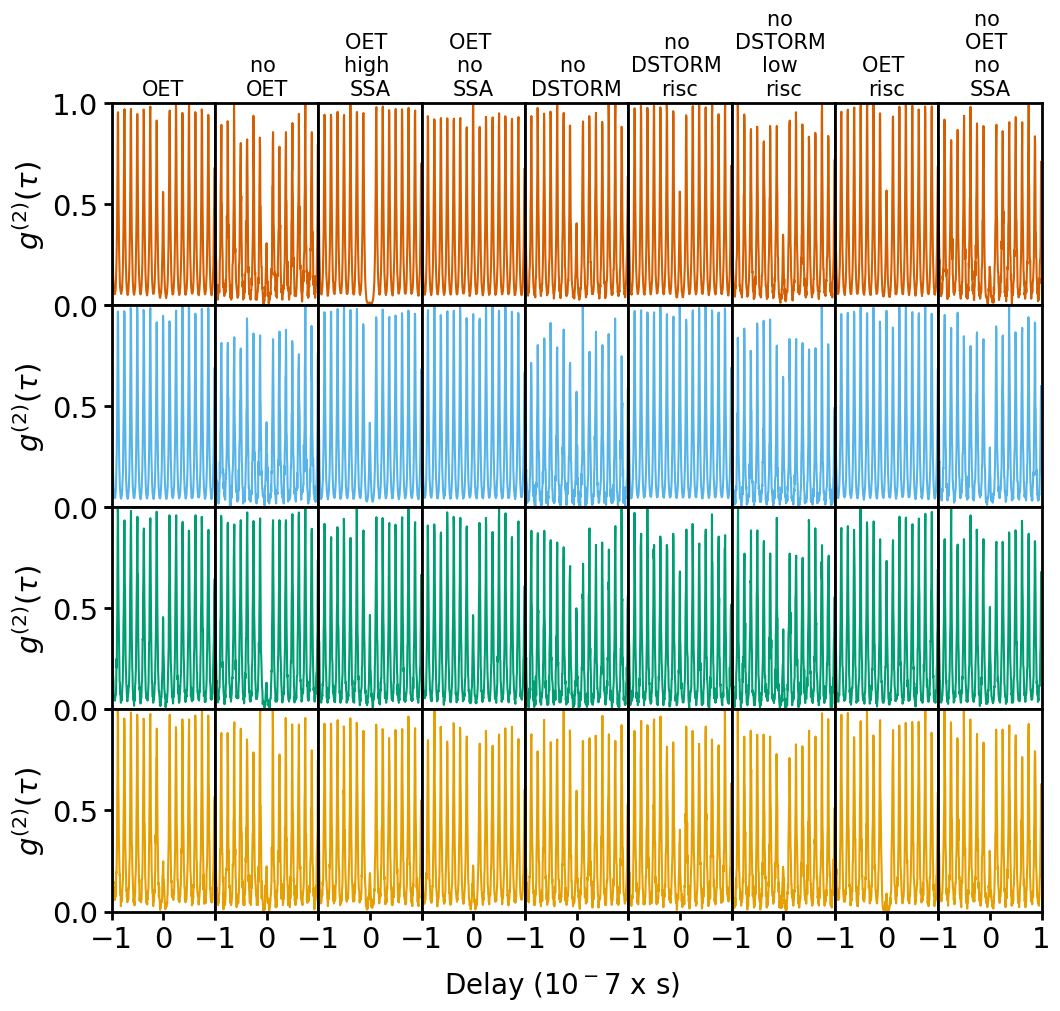

In [28]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(4, 9, wspace=0, hspace=0)
fig = plt.figure(figsize=(12, 10.5))

identifiers = ["3nm", "6nm", "9nm", "18nm"]
col_titles = [
    "OET",
    "no \nOET",
    "OET \nhigh \nSSA",
    "OET \nno \nSSA",
    "no \nDSTORM",
    "no \nDSTORM \nrisc",
    "no \nDSTORM \nlow \nrisc",
    "OET \nrisc",
    "no \nOET \nno \nSSA",
]
for i, _ in enumerate(all_folders):
    for j, _ in enumerate(identifiers):
        if j >= len(all_data_coincidence[i]):
            continue
        hist, bins = all_data_coincidence[i][j]
        ax = fig.add_subplot(gs[j, i])
        fi.universal_figure(
            axes=ax,
            type_="line",
            data=[bins[:-2], hist / np.max(hist)],
            ylim=[0, 1],
            ylabel=r"$g^{(2)}(\tau)$",
            xlim=[-1e-7, 1e-7],
            xlabel="Delay (s)",
            color=colors[j],
            tick_style_x="sci",
        )
        if j == 0:
            ax.set_title(col_titles[i], fontsize=15)
        else:
            ax.get_yticklabels()[-1].set_visible(False)
        if i != 0:
            ax.set_yticklabels([])
            ax.set_yticks([])
            ax.set_ylabel("")
        if i != len(all_folders) - 1:
            ax.get_xticklabels()[-1].set_visible(False)
        if j != len(identifiers) - 1:
            ax.set_xticklabels([])
            ax.set_xticks([])
        ax.set_xlabel("")

fig.text(0.5, 0.04, r"Delay ($10^-7$ x s)", ha="center", va="center", fontsize=20)

# fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])

## Coincidence plots truncated

Text(0.5, 0.04, 'Delay ($10^-7$ x s)')

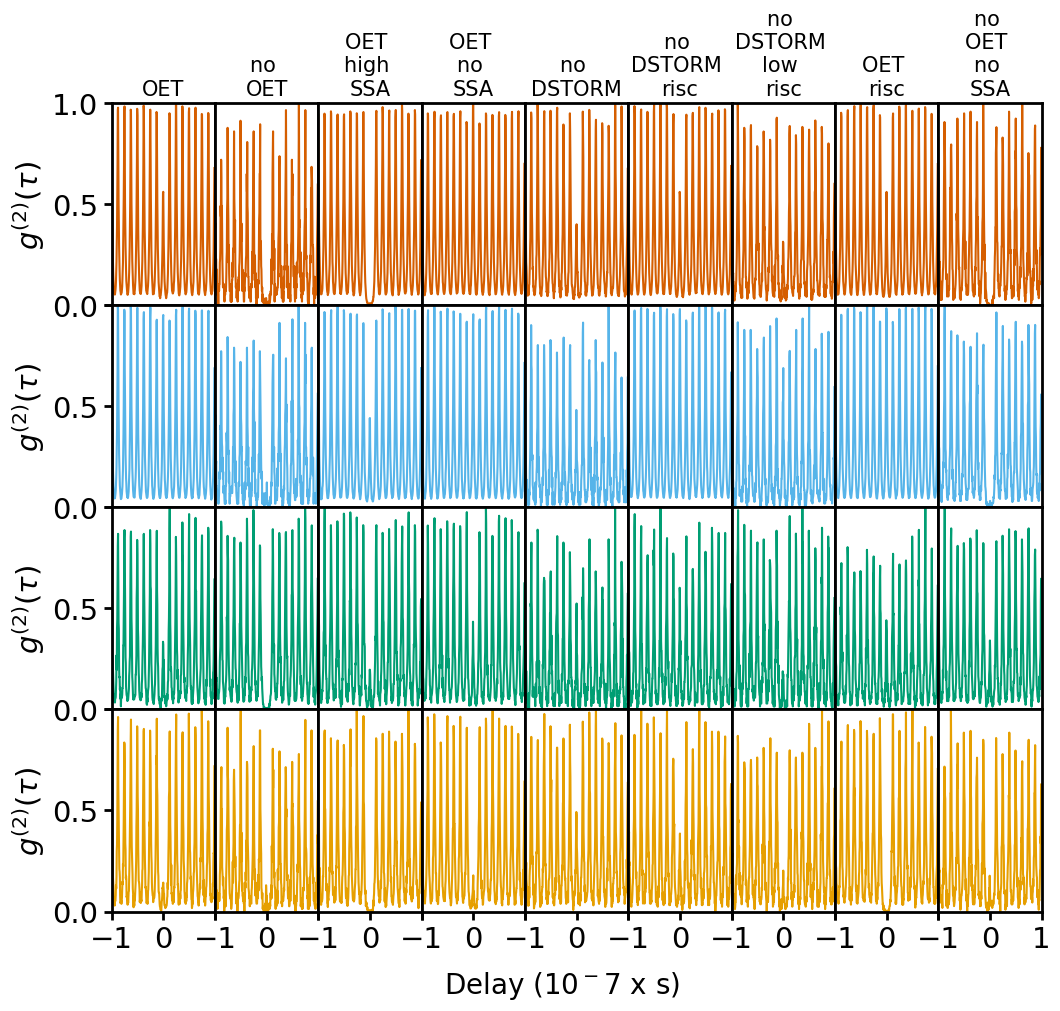

In [29]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(4, 9, wspace=0, hspace=0)
fig = plt.figure(figsize=(12, 10.5))

identifiers = ["3nm", "6nm", "9nm", "18nm"]
col_titles = [
    "OET",
    "no \nOET",
    "OET \nhigh \nSSA",
    "OET \nno \nSSA",
    "no \nDSTORM",
    "no \nDSTORM \nrisc",
    "no \nDSTORM \nlow \nrisc",
    "OET \nrisc",
    "no \nOET \nno \nSSA",
]
for i, _ in enumerate(all_folders):
    for j, _ in enumerate(identifiers):
        if j >= len(all_data_coincidence_truncated[i]):
            continue
        hist, bins = all_data_coincidence_truncated[i][j]
        ax = fig.add_subplot(gs[j, i])
        fi.universal_figure(
            axes=ax,
            type_="line",
            data=[bins[:-2], hist / np.max(hist)],
            ylim=[0, 1],
            ylabel=r"$g^{(2)}(\tau)$",
            xlim=[-1e-7, 1e-7],
            xlabel="Delay (s)",
            color=colors[j],
            tick_style_x="sci",
        )
        if j == 0:
            ax.set_title(col_titles[i], fontsize=15)
        else:
            ax.get_yticklabels()[-1].set_visible(False)
        if i != 0:
            ax.set_yticklabels([])
            ax.set_yticks([])
            ax.set_ylabel("")
        if i != len(all_folders) - 1:
            ax.get_xticklabels()[-1].set_visible(False)
        if j != len(identifiers) - 1:
            ax.set_xticklabels([])
            ax.set_xticks([])
        ax.set_xlabel("")

fig.text(0.5, 0.04, r"Delay ($10^-7$ x s)", ha="center", va="center", fontsize=20)

# fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])

## Fluorescence trajectories

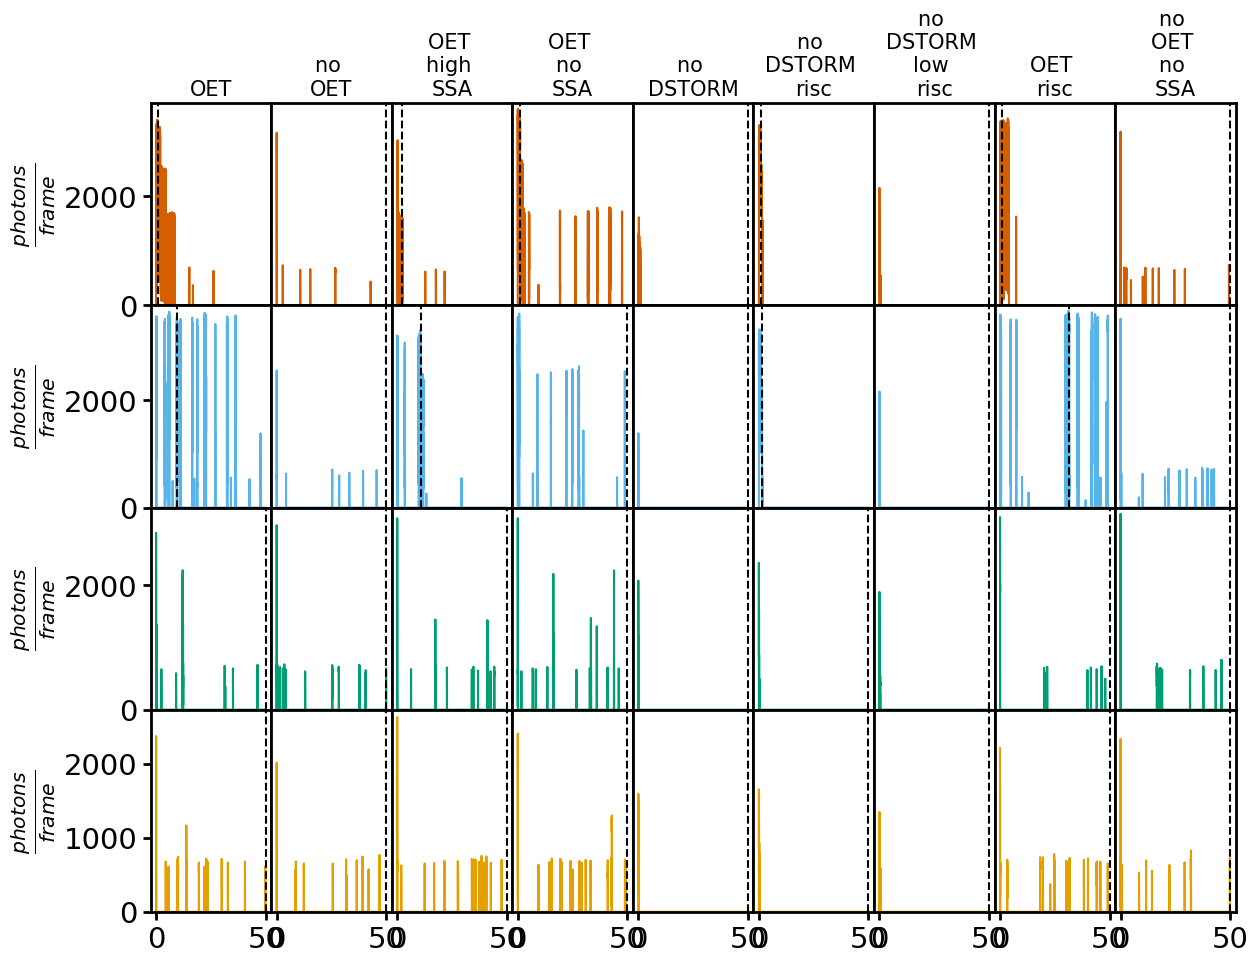

: 

In [ ]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(
    4,
    9,
    wspace=0,
    hspace=0,
)
fig = plt.figure(figsize=(14, 10.5))

identifiers = ["3nm", "6nm", "9nm", "18nm"]
col_titles = [
    "OET",
    "no \nOET",
    "OET \nhigh \nSSA",
    "OET \nno \nSSA",
    "no \nDSTORM",
    "no \nDSTORM \nrisc",
    "no \nDSTORM \nlow \nrisc",
    "OET \nrisc",
    "no \nOET \nno \nSSA",
]
for i, _ in enumerate(all_folders):
    for j, _ in enumerate(identifiers):
        emis = all_data_time_series[i][j]
        ax = fig.add_subplot(gs[j, i])
        emis.plot_time_series(axes=ax, color=colors[j])
        ax.set_ylim([0, maxima[:, j].max() + 100])
        cumsum = emis.event_time_series.cumsum()
        max_index = (
            cumsum[cumsum.values > 3000000].index[0]
            if (cumsum.values > 3000000).any()
            else cumsum.index[-1]
        )
        ax.axvline(max_index, color="black", linestyle="--")
        if j == 0:
            ax.set_title(col_titles[i], fontsize=15)
        else:
            ax.get_yticklabels()[-1].set_visible(False)
        if i != 0:
            ax.set_yticklabels([])
            ax.set_yticks([])
            ax.set_ylabel("")
        if i != len(all_folders) - 1:
            ax.get_xticklabels()[-1].set_visible(False)
        if j != len(identifiers) - 1:
            ax.set_xticklabels([])
            ax.set_xticks([])
        ax.set_xlabel("")